<a href="https://colab.research.google.com/github/ValeriiSlynko/IT-STEP-Practice/blob/master/Practice_Pandas/ClsWrk3_Psndas(pipepline).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [544]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Додаткові імпорти з вже встановленої бібліотеки scikit-learn:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [545]:
df = pd.read_csv("https://raw.githubusercontent.com/HalyshAnton/IT-Step-Pyton-AI/main/module3/data/Used%20Car%20Dataset.csv", index_col="Unnamed: 0")
#df.drop(columns=['car_name', 'registration_year', 'ownsership', 'transmission'], inplace=True)

Дані про ціни вживаних автомобілів у Індії
* car_name - назва авто у форматі 'рік компанія основна назва'
* registration_year - місяць та рік реєстрації
* ownsership - кількість власників у форматі 'Second owner'
* transmission - тип коробки передач
* insurance_validity - тип страховки
* fuel_type - вид палива
* seats - кількість сидінь
* kms_driven - пробіг
* manufacturing_year - рік виробництва, має тип object, потрібно застосувати astype(int)
* mileage(kmpl) - скільки кілометрів проїде за літр палива
* engine(cc) - об'єм двигуна у мл
* max_power(bhp) - потужність у кінських силах
* torque(Nm) - крутний момент двигуна
* price(in lakhs) - ціна у сто тисяч рупій

[Повний аналіз даних](https://www.kaggle.com/code/abdelrasoul/used-cars-prices-prediction)

* *показуємо табличний dataset з першими 10 рядками*

In [546]:
df.head(10)

,car_name,registration_year,insurance_validity,fuel_type,seats,kms_driven,ownsership,transmission,manufacturing_year,mileage(kmpl),engine(cc),max_power(bhp),torque(Nm),price(in lakhs)
0,2017 Mercedes-Benz S-Class S400,Jul-17,Comprehensive,Petrol,5,56000,First Owner,Automatic,2017,7.810,2996.000,2996.000,333.000,63.750
1,2020 Nissan Magnite Turbo CVT XV Premium Opt BSVI,Jan-21,Comprehensive,Petrol,5,30615,First Owner,Automatic,2020,17.400,999.000,999.000,9863.000,8.990
2,2018 BMW X1 sDrive 20d xLine,Sep-18,Comprehensive,Diesel,5,24000,First Owner,Automatic,2018,20.680,1995.000,1995.000,188.000,23.750
3,2019 Kia Seltos GTX Plus,Dec-19,Comprehensive,Petrol,5,18378,First Owner,Manual,2019,16.500,1353.000,1353.000,13808.000,13.560
4,2019 Skoda Superb LK 1.8 TSI AT,Aug-19,Comprehensive,Petrol,5,44900,First Owner,Automatic,2019,14.670,1798.000,1798.000,17746.000,24.000
5,2017 Honda Jazz 1.2 S i VTEC,Jul-17,Third Party insurance,Petrol,5,42000,First Owner,Manual,2017,18.700,1199.000,1199.000,887.000,5.450
6,2018 Hyundai Grand i10 1.2 Kappa Sportz BSIV,Feb-19,Comprehensive,Petrol,5,36739,First Owner,Manual,2018,18.900,1197.000,1197.000,8186.000,5.120
7,2018 Hyundai Creta 1.6 SX,Jul-18,Comprehensive,Petrol,5,76000,First Owner,Manual,2018,15.800,1591.000,1591.000,1213.000,9.300
8,2015 Mercedes-Benz S-Class S 350 CDI,Apr-15,Comprehensive,Diesel,5,68000,Second Owner,Automatic,2015,13.500,2987.000,2987.000,25479.000,42.000
9,2019 Tata Nexon 1.2 Revotron XZ Plus,Mar-19,Comprehensive,Petrol,5,28783,First Owner,Manual,2019,17.000,1198.000,1198.000,1085.000,8.020


In [547]:
# У ХОДІ ОТРИМАНИХ ДАНИХ У PIPELINE потрібно зменшити кількість стовпчиків.  ВИДАЛЯЄМО НАЙБІЛЬШ ВПЛИВОВИЙ СТОВПЧИК
df = df.drop(columns='car_name')

# Завдання 1 *Очистіть дані від викидів, розділіть на тренувальну та тестову частини*

* *Вивід інформації про таблицю (кількість рядків, стовпчиків та типи даних)*

In [548]:
# визначаємо кількість рядків та стовпчиків
rows, columns = df.shape
print(f"Таблиця має '{rows}' рядків та '{columns}' стовпчиків/колнок")

Таблиця має '1553' рядків та '13' стовпчиків/колнок


In [549]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1553 entries, 0 to 1552
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   registration_year   1553 non-null   object 
 1   insurance_validity  1553 non-null   object 
 2   fuel_type           1553 non-null   object 
 3   seats               1553 non-null   int64  
 4   kms_driven          1553 non-null   int64  
 5   ownsership          1553 non-null   object 
 6   transmission        1553 non-null   object 
 7   manufacturing_year  1553 non-null   object 
 8   mileage(kmpl)       1550 non-null   float64
 9   engine(cc)          1550 non-null   float64
 10  max_power(bhp)      1550 non-null   float64
 11  torque(Nm)          1549 non-null   float64
 12  price(in lakhs)     1553 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 169.9+ KB


* *Вивід кількості пропущених значень по стовпчиках*

In [550]:
df.isna().sum()

,0
registration_year,0
insurance_validity,0
fuel_type,0
seats,0
kms_driven,0
ownsership,0
transmission,0
manufacturing_year,0
mileage(kmpl),3
engine(cc),3


* *Вивід типів даних по стовпчиках*

In [551]:
df.dtypes

,0
registration_year,object
insurance_validity,object
fuel_type,object
seats,int64
kms_driven,int64
ownsership,object
transmission,object
manufacturing_year,object
mileage(kmpl),float64
engine(cc),float64


* *Вивід гістограм для всіх числових стовпчиків*

Text(0.5, 0, 'rupees')

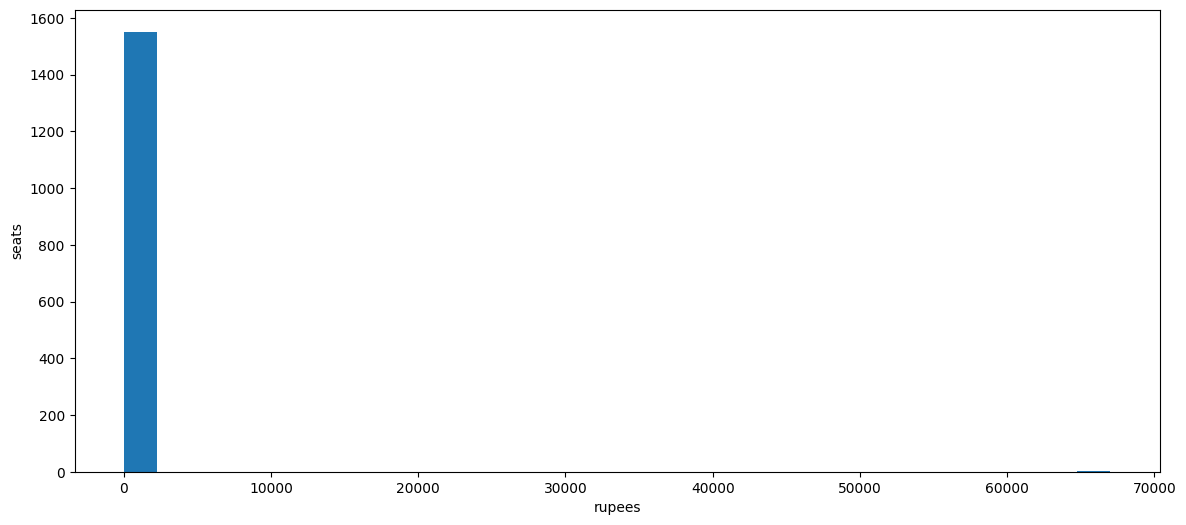

In [552]:
ax = df['seats'].plot(kind='hist',           # тип діаграми hist
                             bins=30,        # кількість стовпчиків
                             figsize=(14,6)  # розмір зображення(в дюймах)
                             )


ax.set_ylabel('seats')
ax.set_xlabel('rupees')

Text(0.5, 0, 'rupees')

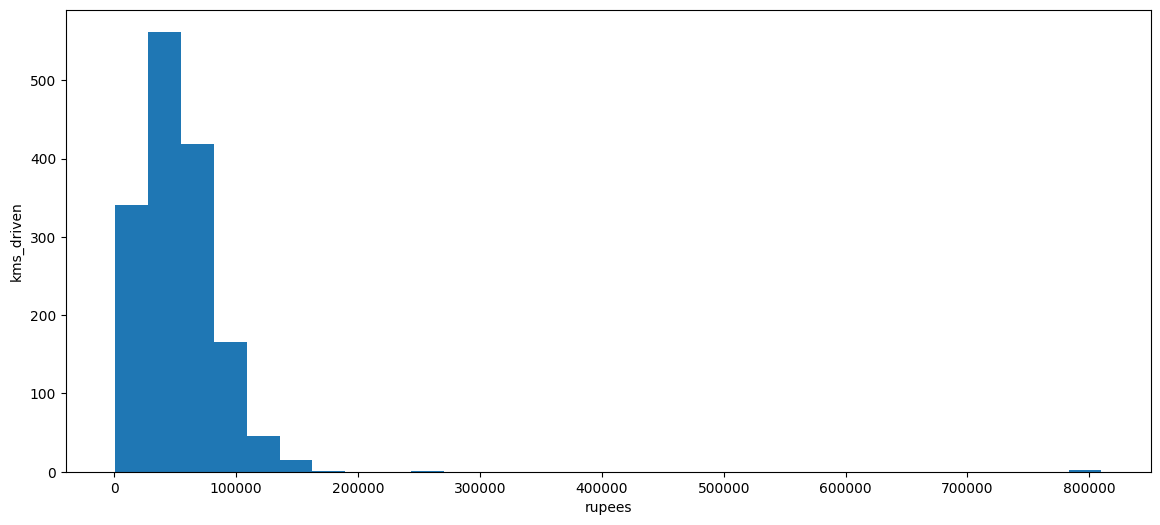

In [553]:
ax = df['kms_driven'].plot(kind='hist',           # тип діаграми hist
                             bins=30,        # кількість стовпчиків
                             figsize=(14,6)  # розмір зображення(в дюймах)
                             )


ax.set_ylabel('kms_driven')
ax.set_xlabel('rupees')

Text(0.5, 0, 'amounth')

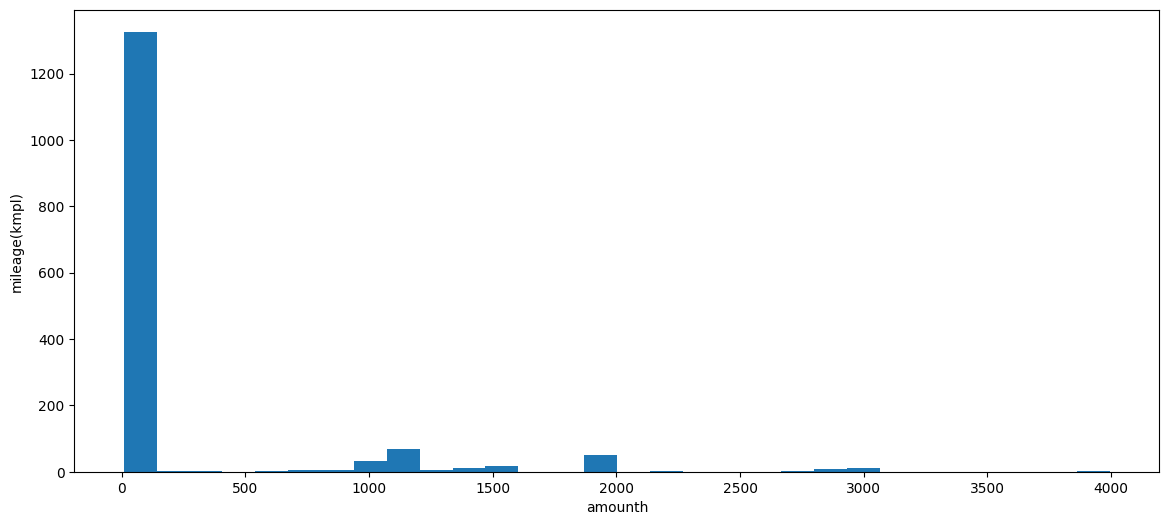

In [554]:
ax = df['mileage(kmpl)'].plot(kind='hist',    # тип діаграми hist
                             bins=30,        # кількість стовпчиків
                             figsize=(14,6)  # розмір зображення(в дюймах)
                             )


ax.set_ylabel('mileage(kmpl)')
ax.set_xlabel('amounth')

Text(0.5, 0, 'amounth')

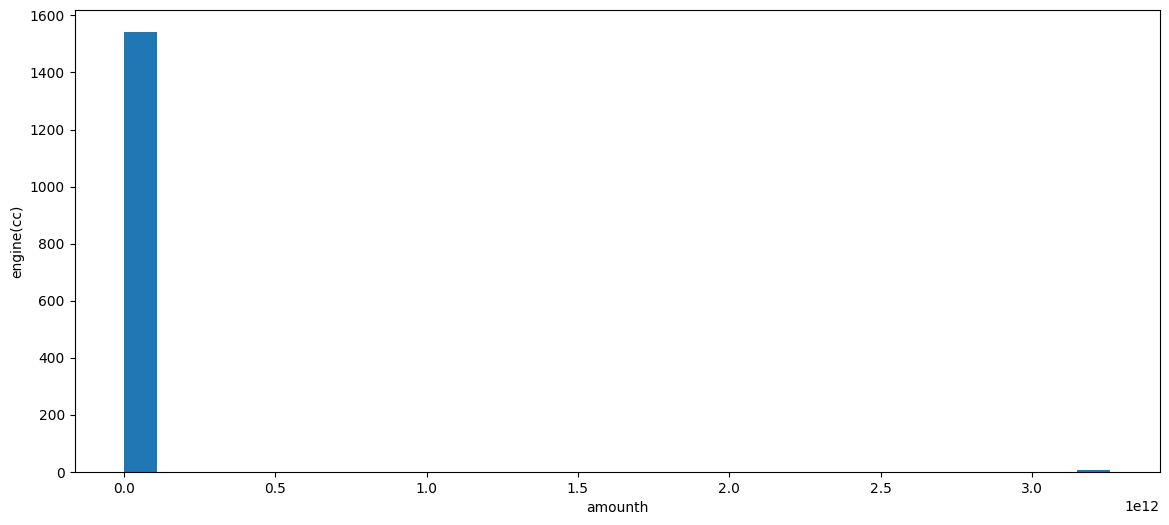

In [555]:
ax = df['engine(cc)'].plot(kind='hist',    # тип діаграми hist
                             bins=30,        # кількість стовпчиків
                             figsize=(14,6)  # розмір зображення(в дюймах)
                             )


ax.set_ylabel('engine(cc)')
ax.set_xlabel('amounth')

Text(0.5, 0, 'rupees')

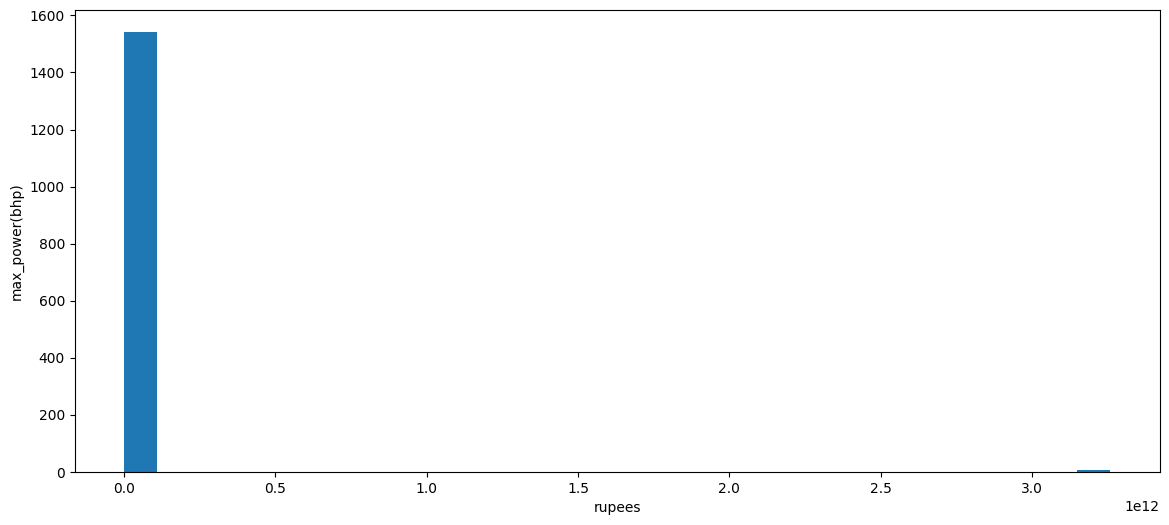

In [556]:
ax = df['max_power(bhp)'].plot(kind='hist',           # тип діаграми hist
                             bins=30,        # кількість стовпчиків
                             figsize=(14,6)  # розмір зображення(в дюймах)
                             )


ax.set_ylabel('max_power(bhp)')
ax.set_xlabel('rupees')

Text(0.5, 0, 'rupees')

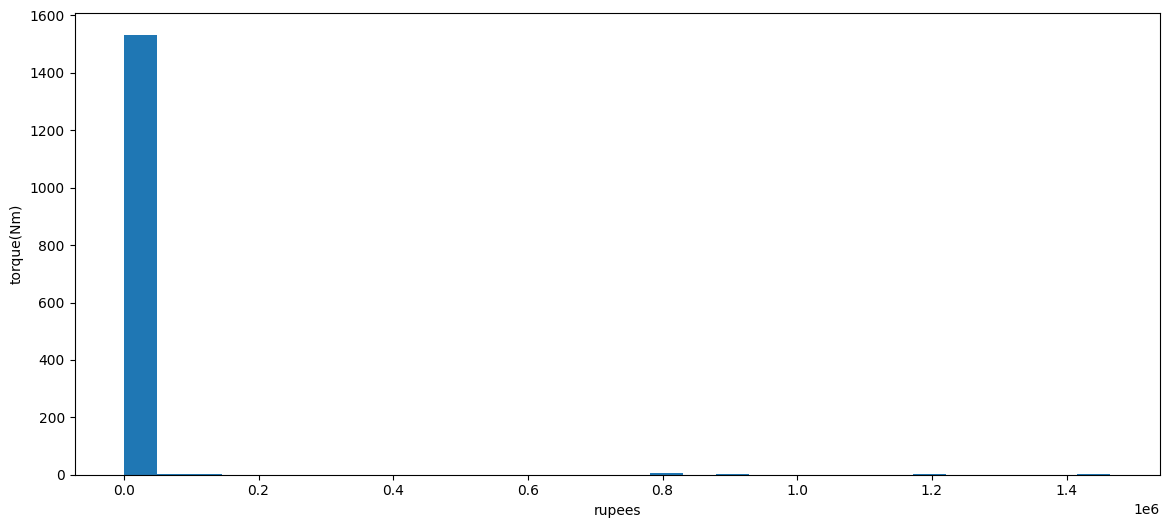

In [557]:
ax = df['torque(Nm)'].plot(kind='hist',           # тип діаграми hist
                             bins=30,        # кількість стовпчиків
                             figsize=(14,6)  # розмір зображення(в дюймах)
                             )


ax.set_ylabel('torque(Nm)')
ax.set_xlabel('rupees')

Text(0.5, 0, 'rupees')

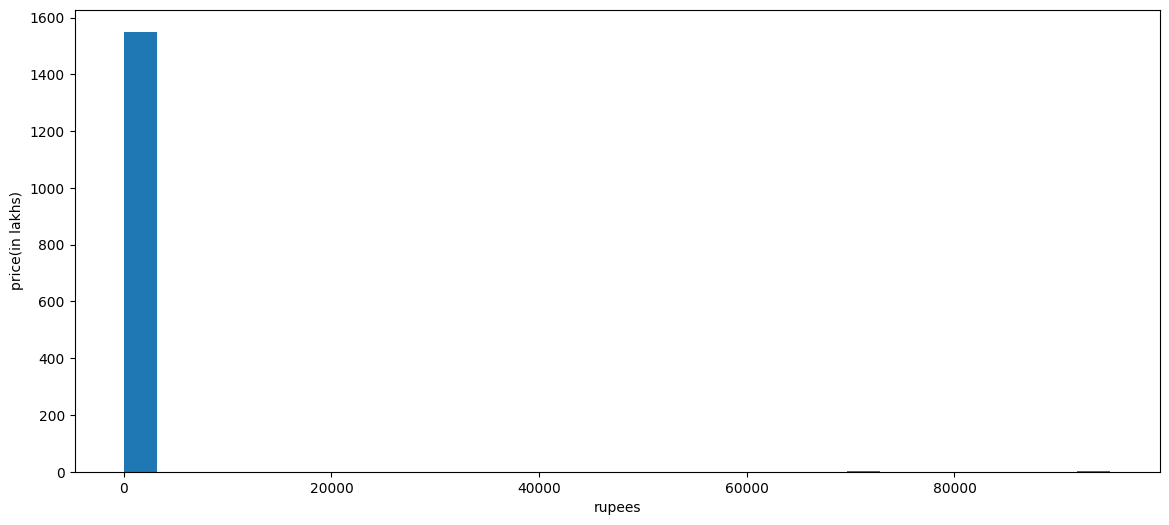

In [558]:
ax = df['price(in lakhs)'].plot(kind='hist',           # тип діаграми hist
                             bins=30,        # кількість стовпчиків
                             figsize=(14,6)  # розмір зображення(в дюймах)
                             )


ax.set_ylabel('price(in lakhs)')
ax.set_xlabel('rupees')

* *Вивід ящиків з вусами для всіх числових стовпчиків. Де потрібно очистіть викиди (побудова "boxplot")*

  *Застосування mask*

In [559]:
# очистка даних/викидів із застосуванням маски
mask = df['seats'] < 1000
mask.sum()

np.int64(1551)

In [560]:
df = df[mask]

Text(0.5, 0, 'Seats (кількість сидінь в авто)')

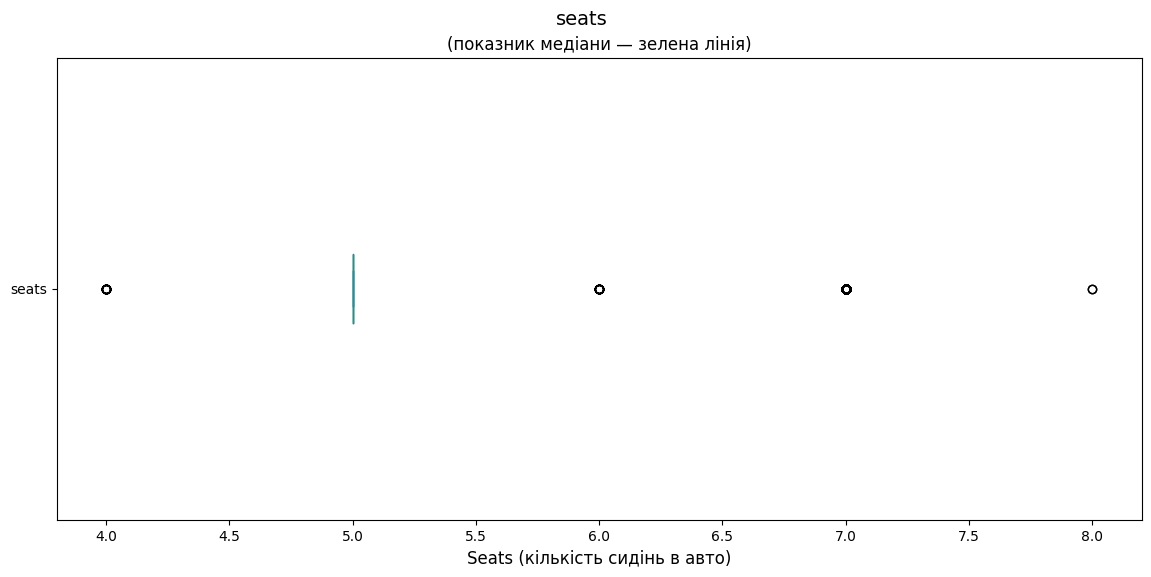

In [561]:
# малюємо ящик з вусами 'Seats' (кількість сидінь)
ax = df['seats'].plot(kind='box', vert=False, figsize=(14, 6))

# Додаємо заголовки та підписи
plt.suptitle('seats', fontsize=14, y=0.96)
ax.set_title('(показник медіани — зелена лінія)', fontsize=12)
ax.set_xlabel('Seats (кількість сидінь в авто)', fontsize=12)

In [562]:
mask = df['kms_driven'] < 200000
mask.sum()

np.int64(1548)

In [563]:
df = df[mask]

In [564]:
mask = df['kms_driven'] < 175000
mask.sum()

np.int64(1547)

In [565]:
df = df[mask]

Text(0.5, 0, 'Kilometers (пробіг авто)')

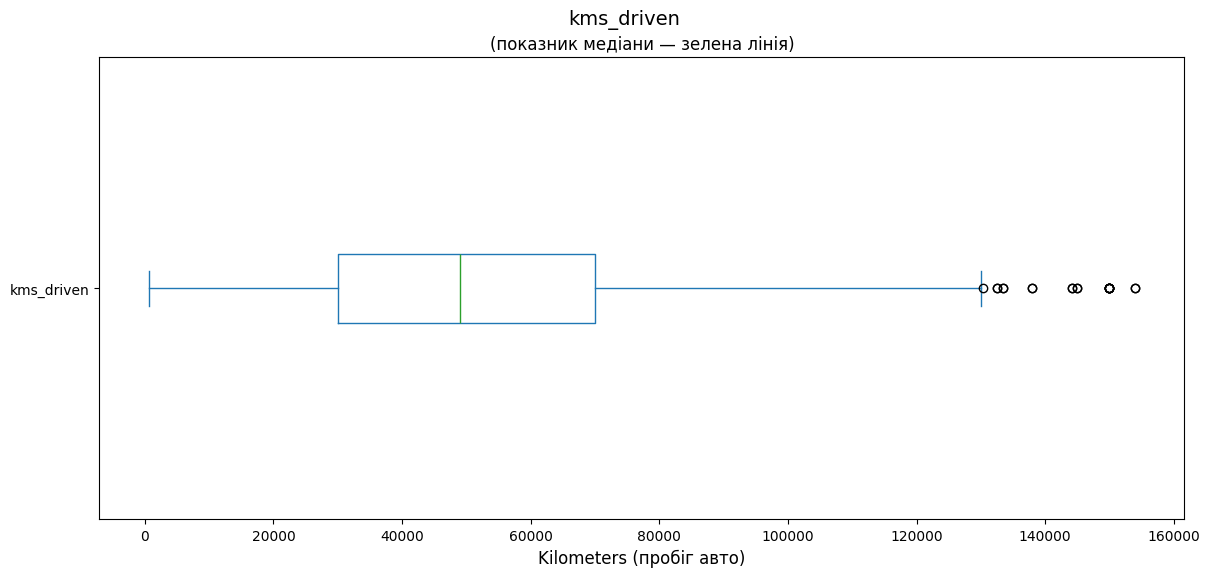

In [566]:
# малюємо ящик з вусами 'kms_driven' (пробіг авто)
ax = df['kms_driven'].plot(kind='box', vert=False, figsize=(14, 6))

# Додаємо заголовки та підписи
plt.suptitle('kms_driven', fontsize=14, y=0.96)
ax.set_title('(показник медіани — зелена лінія)', fontsize=12)
ax.set_xlabel('Kilometers (пробіг авто)', fontsize=12)

In [567]:
mask = df['mileage(kmpl)'] < 50
mask.sum()

np.int64(1322)

In [568]:
df = df[mask]

Text(0.5, 0, 'kilometers per liter (Пробіг за 1л палива)')

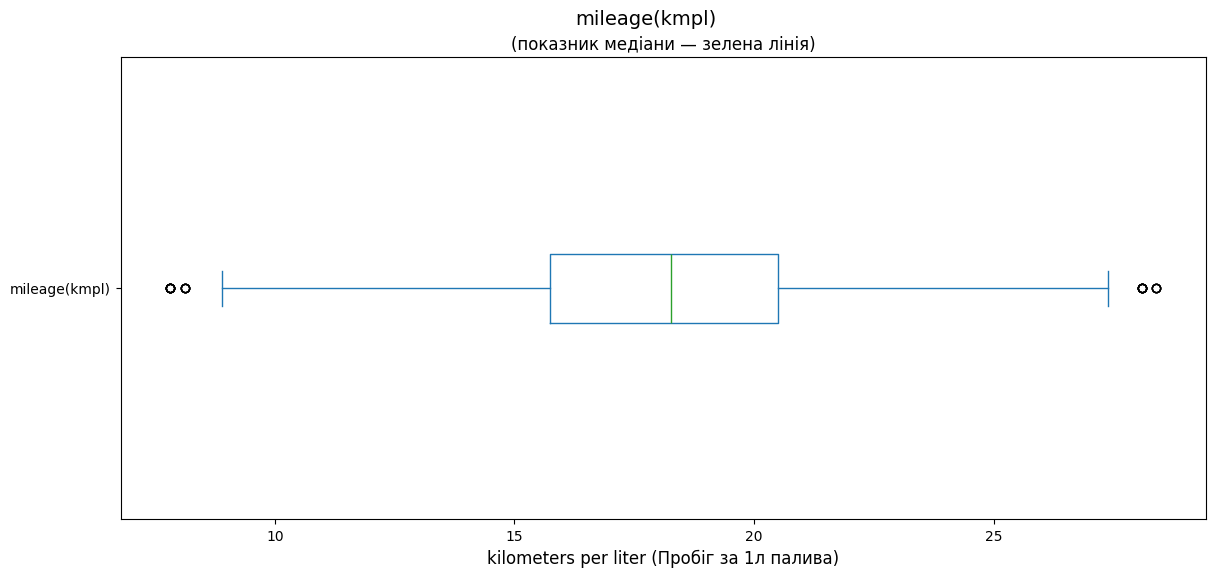

In [569]:
# малюємо ящик з вусами 'mileage(kmpl)' (скільки кілометрів проїде за літр палива)
ax = df['mileage(kmpl)'].plot(kind='box', vert=False, figsize=(14, 6))

# Додаємо заголовки та підписи
plt.suptitle('mileage(kmpl)', fontsize=14, y=0.96)
ax.set_title('(показник медіани — зелена лінія)', fontsize=12)
ax.set_xlabel('kilometers per liter (Пробіг за 1л палива)', fontsize=12)

In [570]:
mask = df['engine(cc)'] < 5000
mask.sum()

np.int64(1320)

In [571]:
df = df[mask]

Text(0.5, 0, "Engine displacement (об'єм двигуна)")

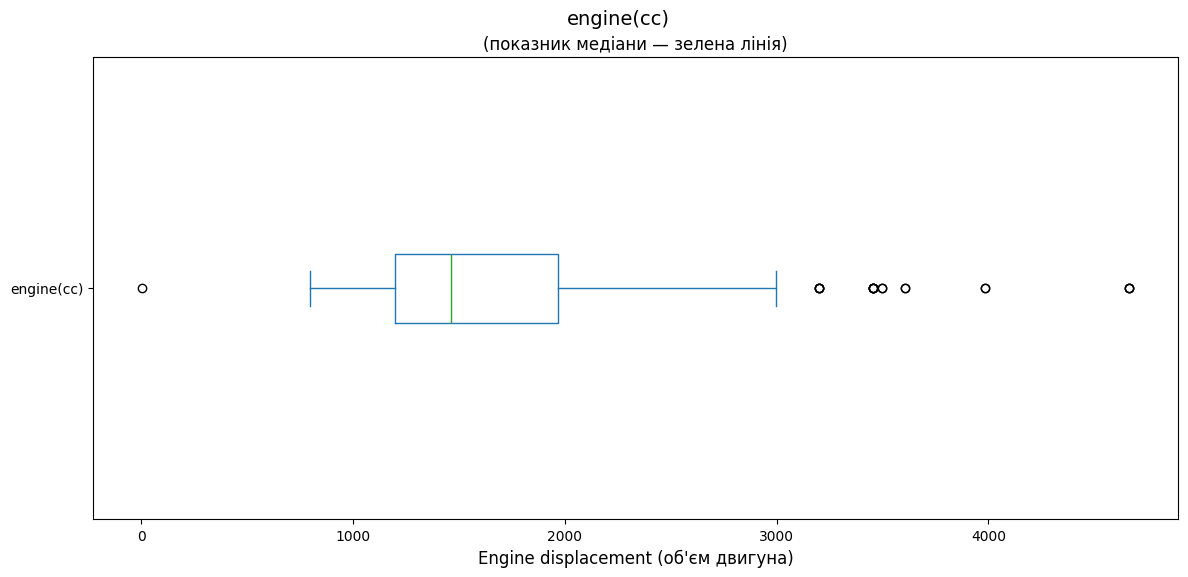

In [572]:
# малюємо ящик з вусами 'engine(cc)' (об'єм двигуна)
ax = df['engine(cc)'].plot(kind='box', vert=False, figsize=(14, 6))

# Додаємо заголовки та підписи
plt.suptitle('engine(cc)', fontsize=14, y=0.96)
ax.set_title('(показник медіани — зелена лінія)', fontsize=12)
ax.set_xlabel("Engine displacement (об'єм двигуна)", fontsize=12)

Text(0.5, 0, 'Engine power (потужність двигуна)')

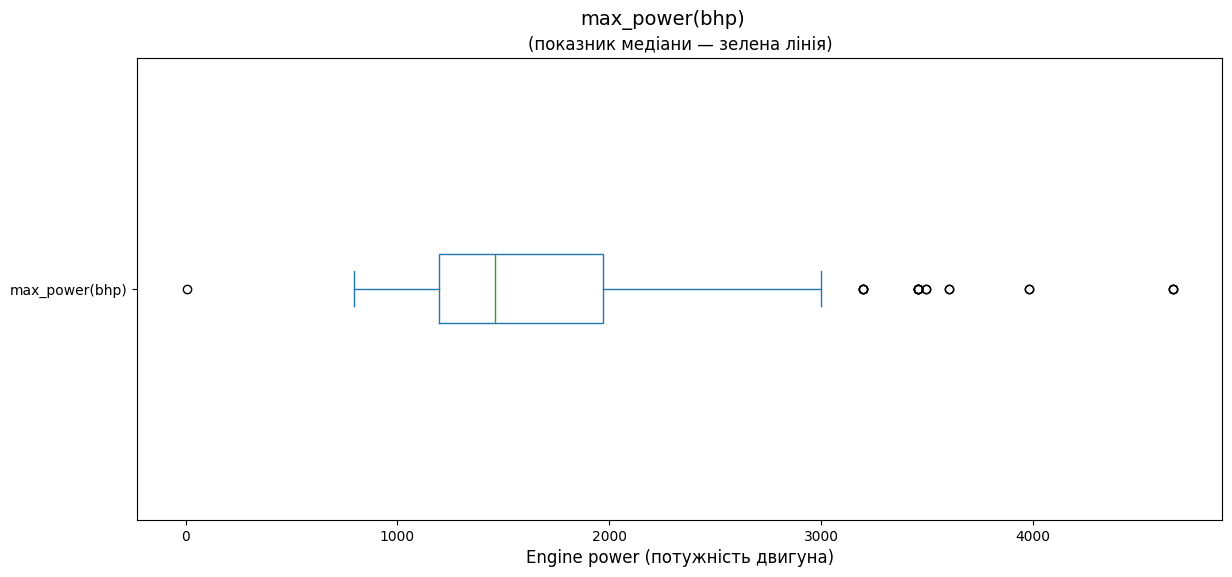

In [573]:
# малюємо ящик з вусами 'max_power(bhp)' (потужність двигуна у кінських силах)
ax = df['max_power(bhp)'].plot(kind='box', vert=False, figsize=(14, 6))

# Додаємо заголовки та підписи
plt.suptitle('max_power(bhp)', fontsize=14, y=0.96)
ax.set_title('(показник медіани — зелена лінія)', fontsize=12)
ax.set_xlabel("Engine power (потужність двигуна)", fontsize=12)

In [574]:
mask = df['torque(Nm)'] < 40000
mask.sum()

np.int64(1305)

In [575]:
df = df[mask]

Text(0.5, 0, 'Engine torque(Nm) (крутний момент двигуна)')

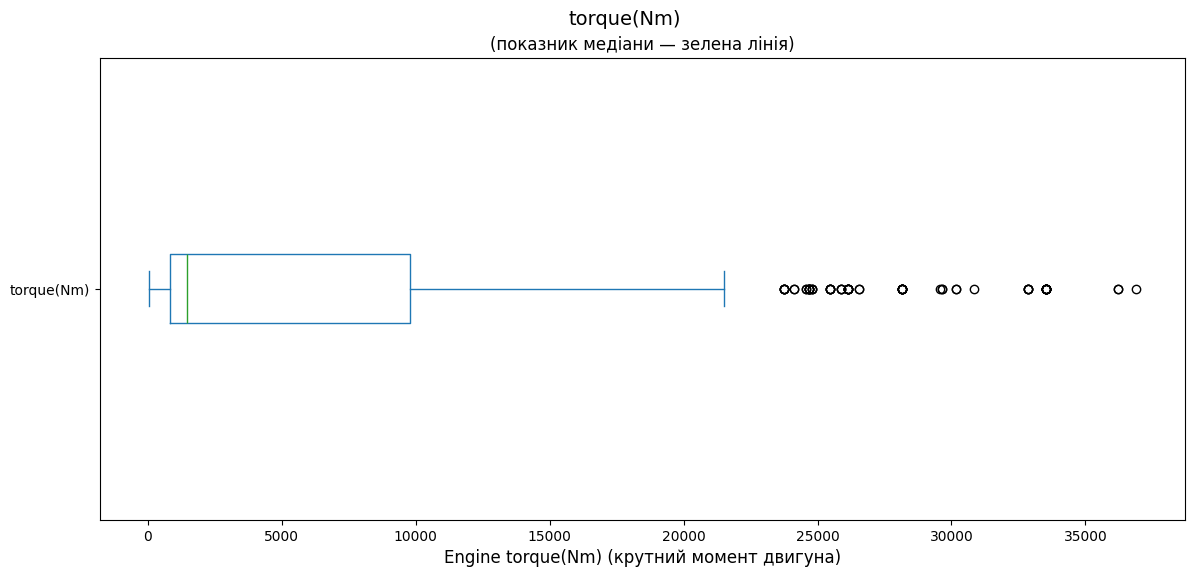

In [576]:
# малюємо ящик з вусами 'max_power(bhp)' (крутний  момент двигуна(Nm))
ax = df['torque(Nm)'].plot(kind='box', vert=False, figsize=(14, 6))

# Додаємо заголовки та підписи
plt.suptitle('torque(Nm)', fontsize=14, y=0.96)
ax.set_title('(показник медіани — зелена лінія)', fontsize=12)
ax.set_xlabel("Engine torque(Nm) (крутний момент двигуна)", fontsize=12)

In [577]:
mask = df['price(in lakhs)'] < 20000
mask.sum()

np.int64(1304)

In [578]:
df = df[mask]

Text(0.5, 0, 'Price (ціна у сто тисяч рупій)')

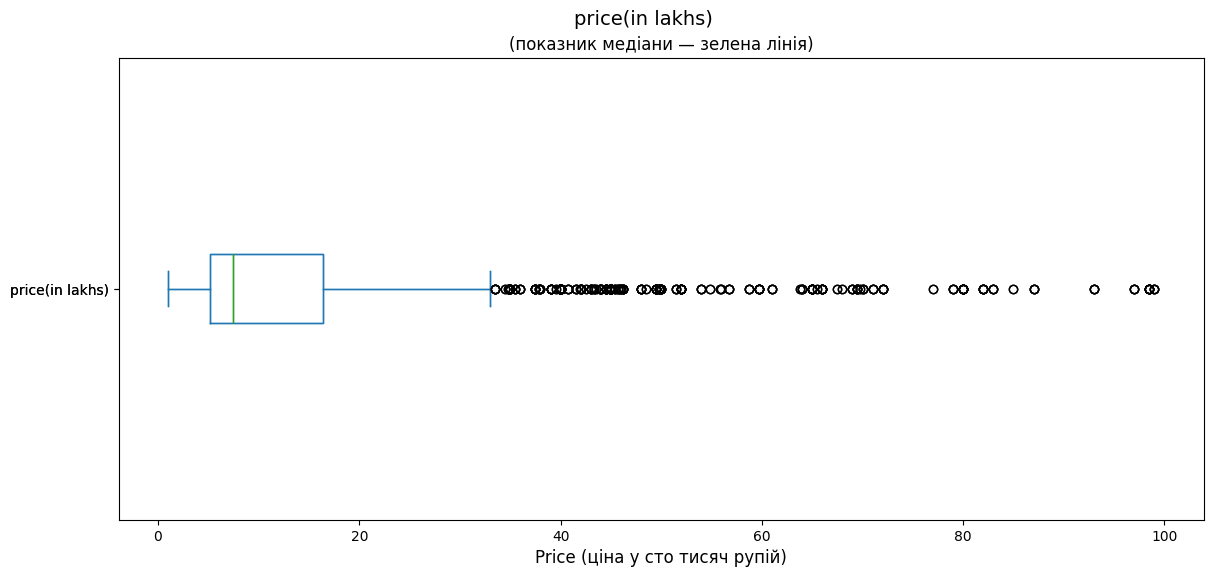

In [579]:
df['price(in lakhs)'].plot(kind='box', vert=False, figsize=(14,6))
# малюємо ящик з вусами 'price(in lakhs)' (ціна у сто тисяч Рупій)
ax = df['price(in lakhs)'].plot(kind='box', vert=False, figsize=(14, 6))

# Додаємо заголовки та підписи
plt.suptitle('price(in lakhs)', fontsize=14, y=0.96)
ax.set_title('(показник медіани — зелена лінія)', fontsize=12)
ax.set_xlabel("Price (ціна у сто тисяч рупій)", fontsize=12)

# *Підготовка даних на тренувальну та тестову частини*

In [580]:
y = df['price(in lakhs)']
X = df.drop(columns='price(in lakhs)')
X

,registration_year,insurance_validity,fuel_type,seats,kms_driven,ownsership,transmission,manufacturing_year,mileage(kmpl),engine(cc),max_power(bhp),torque(Nm)
0,Jul-17,Comprehensive,Petrol,5,56000,First Owner,Automatic,2017,7.810,2996.000,2996.000,333.000
1,Jan-21,Comprehensive,Petrol,5,30615,First Owner,Automatic,2020,17.400,999.000,999.000,9863.000
2,Sep-18,Comprehensive,Diesel,5,24000,First Owner,Automatic,2018,20.680,1995.000,1995.000,188.000
3,Dec-19,Comprehensive,Petrol,5,18378,First Owner,Manual,2019,16.500,1353.000,1353.000,13808.000
4,Aug-19,Comprehensive,Petrol,5,44900,First Owner,Automatic,2019,14.670,1798.000,1798.000,17746.000
...,...,...,...,...,...,...,...,...,...,...,...,...
1546,May-18,Comprehensive,Petrol,5,19446,First Owner,Automatic,2018,18.200,1199.000,1199.000,887.000
1547,May-22,Third Party insurance,CNG,7,26500,First Owner,Manual,2022,26.110,1462.000,1462.000,8663.000
1550,Jun-17,Comprehensive,Petrol,5,49000,First Owner,Manual,2017,17.500,1199.000,1199.000,887.000
1551,May-18,Comprehensive,Petrol,5,40000,Second Owner,Manual,2018,18.780,999.000,999.000,75.000


In [581]:
y

,price(in lakhs)
0,63.750
1,8.990
2,23.750
3,13.560
4,24.000
...,...
1546,6.500
1547,11.500
1550,5.850
1551,4.750


# *Розділення на тренувальну та тестову частини*

In [582]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Розподіл даних на тренувальну (80%) та тестову (20%) вибірки
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% даних іде на тест, 80% на тренування
    random_state=42,    # Фіксація випадкового стану для відтворюваності
    )
# -де ' train_test_split ' - назва функції

* *Вивід розмірів dataset (тренувальний та тестових)*

In [583]:
X_train.shape

(1043, 12)

In [584]:
X_test.shape

(261, 12)

In [585]:
y_train.shape

(1043,)

In [586]:
y_test.shape

(261,)

# Завдання 2 *Створіть Pipeline для обробки даних*

In [587]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Визначення числових та категоріальних колонок
num_features = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_features = X_train.select_dtypes(include=['object', 'category']).columns

# Пайплайн для числових даних
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

# Пайплайн для категоріальних даних
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OneHotEncoder(handle_unknown='ignore',sparse_output=False))
])

# Об'єднання в один препроцесор
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

# Застосування до тренувальних та тестових даних
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)



* *Вивід ЧИСЛОВИХ СТОВПЧИКІВ 'num_features' для ознайомлення*

In [588]:
num_features

Index(['seats', 'kms_driven', 'mileage(kmpl)', 'engine(cc)', 'max_power(bhp)', 'torque(Nm)'], dtype='object')

* *Вивід СТОВПЧИКІВ із 'str' рядками -"num_features" для ознайомлення*

In [589]:
cat_features

Index(['registration_year', 'insurance_validity', 'fuel_type', 'ownsership', 'transmission', 'manufacturing_year'], dtype='object')

* *Вивід 'preprocessor' (об'єднання num_pipeline & cat_pipeline) на екран для ознайомлення*

In [590]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 Index(['seats', 'kms_driven', 'mileage(kmpl)', 'engine(cc)', 'max_power(bhp)', 'torque(Nm)'], dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='Unknown',
                                                                strategy='constant')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 Index(['registration_year', 'insurance_validity', 'fuel_type', 'ownsership', 'transmission', 'manufacturing_year'], dtype='object'))])

In [591]:
preprocessor.set_output(transform="pandas")

# 3. Трансформація даних
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

# 4. Налаштування гарного виводу в консоль
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

In [592]:
X_train

,registration_year,insurance_validity,fuel_type,seats,kms_driven,ownsership,transmission,manufacturing_year,mileage(kmpl),engine(cc),max_power(bhp),torque(Nm)
1163,Sep-22,Comprehensive,Petrol,5,22000,Second Owner,Automatic,2022,14.820,1998.000,1998.000,18908.000
1148,Oct-18,Comprehensive,Petrol,5,74000,First Owner,Manual,2018,17.800,1198.000,1198.000,867.000
10,Mar-20,Comprehensive,Petrol,5,40000,First Owner,Automatic,2020,17.400,1497.000,1497.000,1176.000
166,Jul-18,Third Party insurance,Petrol,5,32000,First Owner,Automatic,2018,15.040,1991.000,1991.000,183.000
420,Oct-17,Third Party insurance,Petrol,5,67000,First Owner,Manual,2017,20.730,1373.000,1373.000,911.000
...,...,...,...,...,...,...,...,...,...,...,...,...
1308,Feb-18,Comprehensive,Petrol,5,34260,First Owner,Manual,2018,21.500,1197.000,1197.000,8180.000
1354,Nov-14,Comprehensive,Diesel,5,71649,First Owner,Manual,2014,23.590,1364.000,1364.000,6704.000
1540,Aug-22,Comprehensive,Petrol,5,19000,First Owner,Manual,2022,20.090,1199.000,1199.000,8482.000
1014,May-15,Comprehensive,Petrol,5,105446,First Owner,Manual,2015,18.900,1197.000,1197.000,82.000


In [593]:
X_train_prepared

,num__seats,num__kms_driven,num__mileage(kmpl),num__engine(cc),num__max_power(bhp),num__torque(Nm),cat__registration_year_2009,cat__registration_year_2010,cat__registration_year_2012,cat__registration_year_2013,cat__registration_year_2014,cat__registration_year_2015,cat__registration_year_2016,cat__registration_year_2017,cat__registration_year_2018,cat__registration_year_2019,cat__registration_year_2020,cat__registration_year_2021,cat__registration_year_2022,cat__registration_year_2023,cat__registration_year_Apr-12,cat__registration_year_Apr-13,cat__registration_year_Apr-15,cat__registration_year_Apr-16,cat__registration_year_Apr-17,cat__registration_year_Apr-18,cat__registration_year_Apr-19,cat__registration_year_Apr-20,cat__registration_year_Apr-21,cat__registration_year_Apr-22,cat__registration_year_Apr-23,cat__registration_year_Aug-11,cat__registration_year_Aug-13,cat__registration_year_Aug-14,cat__registration_year_Aug-15,cat__registration_year_Aug-16,cat__registration_year_Aug-17,cat__registration_year_Aug-18,cat__registration_year_Aug-19,cat__registration_year_Aug-20,cat__registration_year_Aug-21,cat__registration_year_Aug-22,cat__registration_year_Aug-23,cat__registration_year_Dec-09,cat__registration_year_Dec-12,cat__registration_year_Dec-13,cat__registration_year_Dec-14,cat__registration_year_Dec-15,cat__registration_year_Dec-16,cat__registration_year_Dec-17,cat__registration_year_Dec-18,cat__registration_year_Dec-19,cat__registration_year_Dec-20,cat__registration_year_Dec-21,cat__registration_year_Dec-22,cat__registration_year_Feb-15,cat__registration_year_Feb-16,cat__registration_year_Feb-17,cat__registration_year_Feb-18,cat__registration_year_Feb-19,cat__registration_year_Feb-20,cat__registration_year_Feb-21,cat__registration_year_Feb-22,cat__registration_year_Feb-23,cat__registration_year_Jan-09,cat__registration_year_Jan-11,cat__registration_year_Jan-14,cat__registration_year_Jan-15,cat__registration_year_Jan-16,cat__registration_year_Jan-17,cat__registration_year_Jan-18,cat__registration_year_Jan-19,cat__registration_year_Jan-20,cat__registration_year_Jan-21,cat__registration_year_Jan-22,cat__registration_year_Jan-23,cat__registration_year_Jul-12,cat__registration_year_Jul-13,cat__registration_year_Jul-14,cat__registration_year_Jul-15,cat__registration_year_Jul-16,cat__registration_year_Jul-17,cat__registration_year_Jul-18,cat__registration_year_Jul-19,cat__registration_year_Jul-20,cat__registration_year_Jul-21,cat__registration_year_Jul-22,cat__registration_year_Jul-23,cat__registration_year_Jun-10,cat__registration_year_Jun-11,cat__registration_year_Jun-12,cat__registration_year_Jun-13,cat__registration_year_Jun-14,cat__registration_year_Jun-15,cat__registration_year_Jun-16,cat__registration_year_Jun-17,cat__registration_year_Jun-18,cat__registration_year_Jun-19,cat__registration_year_Jun-20,cat__registration_year_Jun-21,cat__registration_year_Jun-22,cat__registration_year_Mar-09,cat__registration_year_Mar-11,cat__registration_year_Mar-13,cat__registration_year_Mar-14,cat__registration_year_Mar-15,cat__registration_year_Mar-16,cat__registration_year_Mar-17,cat__registration_year_Mar-18,cat__registration_year_Mar-19,cat__registration_year_Mar-20,cat__registration_year_Mar-21,cat__registration_year_Mar-22,cat__registration_year_Mar-23,cat__registration_year_May-10,cat__registration_year_May-11,cat__registration_year_May-12,cat__registration_year_May-13,cat__registration_year_May-14,cat__registration_year_May-15,cat__registration_year_May-16,cat__registration_year_May-17,cat__registration_year_May-18,cat__registration_year_May-19,cat__registration_year_May-21,cat__registration_year_May-22,cat__registration_year_May-23,cat__registration_year_Nov-10,cat__registration_year_Nov-11,cat__registration_year_Nov-12,cat__registration_year_Nov-13,cat__registration_year_Nov-14,cat__registration_year_Nov-15,cat__registration_year_Nov-16,cat__registration_year_Nov-17,cat__registration_year_Nov-18,cat__registration_year_Nov-19

In [594]:
cat_features

Index(['registration_year', 'insurance_validity', 'fuel_type', 'ownsership', 'transmission', 'manufacturing_year'], dtype='object')

In [595]:
X_train_prepared.shape

(1043, 195)

# Завдання 3 *Створіть остаточну модель та натренуйте її*

In [596]:
# Створення єдиного пайплайну (Препроцесор + Одне Дерево)
final_price_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),  # Трансформація: стрінги -> інти
    ('tree_regressor', DecisionTreeRegressor(
        max_depth=6,            # Обмеження глибини, щоб дерево не перенавчалося
        min_samples_leaf=2,     # Мінімальна кількість об'єктів у листку для стабільності
        random_state=42         # Фіксація випадковості для відтворюваності результатів
    ))
])

* *Вивід 'final_price_pipeline'*

In [597]:
final_price_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['seats', 'kms_driven', 'mileage(kmpl)', 'engine(cc)', 'max_power(bhp)', 'torque(Nm)'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Unknown',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['registration_year', 'insurance_validity', 'fuel_type', 'ownsership', 'transmission', 'manufacturing_year'], dtype='object'))])),
                ('tree_regressor',
                 DecisionTreeRegressor(max_depth=6, min_samples_leaf=2,
                                       random_state=42))])

# *Тренуємо МОДЕЛЬ*

In [598]:
# Головна команда для тренування:
final_price_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['seats', 'kms_driven', 'mileage(kmpl)', 'engine(cc)', 'max_power(bhp)', 'torque(Nm)'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Unknown',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['registration_year', 'insurance_validity', 'fuel_type', 'ownsership', 'transmission', 'manufacturing_year'], dtype='object'))])),
                ('tree_regressor',
                 DecisionTreeRegressor(max_depth=6, min_samples_leaf=2,
                                       random_state=42))])

# *Тренуємо МОДЕЛЬ*

In [599]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from google.colab import files  # Модуль для скачування файлів у Colab

# 1. Налаштовуємо полотно та повністю прибираємо графічні рамки
fig, ax = plt.subplots(figsize=(25, 15), dpi=300)
ax.axis('off')

# 2. Малюємо виключно структуру дерева
plot_tree(
    final_price_pipeline.named_steps['tree_regressor'],
    feature_names=final_price_pipeline.named_steps['preprocessor'].get_feature_names_out(),
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax
)

# 3. Зберігаємо у файл без зайвих відступів по краях
output_filename = "decision_tree.pdf"
plt.savefig(output_filename, format='pdf', bbox_inches='tight', pad_inches=0)
plt.close()

# 4. Автоматично скачуємо файл через браузер із Google Colab
files.download(output_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [600]:
pred_price = final_price_pipeline.predict(X_test)


In [601]:
# 2. Створюємо порівняльний DataFrame
results_df = pd.DataFrame({
    'Реальна ціна (Actual)': y_test.values if hasattr(y_test, 'values') else y_test,
    'Прогнозована ціна (Pred)': pred_price,
    'Різниця (Error)': (y_test.values if hasattr(y_test, 'values') else y_test) - pred_price,
    'Абсолютна помилка (|Error|)': abs((y_test.values if hasattr(y_test, 'values') else y_test) - pred_price)
})
results_df

,Реальна ціна (Actual),Прогнозована ціна (Pred),Різниця (Error),Абсолютна помилка (|Error|)
0,4.980,6.424,-1.444,1.444
1,6.330,6.424,-0.094,0.094
2,9.850,6.317,3.533,3.533
3,4.240,4.486,-0.246,0.246
4,7.640,8.505,-0.865,0.865
...,...,...,...,...
256,10.200,10.968,-0.768,0.768
257,7.950,6.424,1.526,1.526
258,6.850,6.424,0.426,0.426
259,36.000,40.658,-4.658,4.658


# Завдання 4 *Виведіть основні метрики моделі*

In [602]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

# 1. Отримуємо прогнози
y_pred = final_price_pipeline.predict(X_test)

# 2. Розраховуємо метрики
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=== ОСНОВНІ МЕТРИКИ МОДЕЛІ ===")
print(f"MAE  (Mean Absolute Error): {mae:.4f}")
print(f"MSE  (Mean Squared Error):  {mse:.4f}")
print(f"RMSE (Root MSE):            {rmse:.4f}")
print(f"R² Score:                   {r2:.4f}")

=== ОСНОВНІ МЕТРИКИ МОДЕЛІ ===
MAE  (Mean Absolute Error): 4.7079
MSE  (Mean Squared Error):  106.0680
RMSE (Root MSE):            10.2989
R² Score:                   0.6722


# Завдання 5 *Змініть параметри моделі та попробуйте покращити результат*

In [603]:
# Було змінені параметри у Створенні єдиного пайплайну
# МОДЕЛЬ 'final_price_pipeline'
# зміна параметрів: max_depth=4 НА max_depth=6,    # Обмеження глибини, щоб дерево не перенавчалося
                  # min_samples_leaf=5 НА min_samples_leaf=2,   # Мінімальна кількість об'єктів у листку для стабільності

# як результат покращений результат


# Завдання 6 *Збережіть модель*

In [605]:
import joblib

# Зберігаємо навчений пайплайн під твоєю назвою
joblib.dump(final_price_pipeline, 'final_price_pipeline.pkl')

print("Модель успішно збережено у файл 'final_price_pipeline.pkl'!")

Модель успішно збережено у файл 'final_price_pipeline.pkl'!
